In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Improved_WiFi_Dataset.csv")

print(df.head())
print(df.info())


   Connected Devices  Network Latency (ms)  Packet Loss (%)  \
0               40.0                  20.2             1.04   
1              106.0                  79.6             4.53   
2               30.0                   NaN             2.23   
3               63.0                 123.3             3.20   
4                NaN                  27.0             3.30   

   Bandwidth Usage (%)  Access Point Load (%)  Signal Strength (dBm)  \
0                 79.3                   47.5                    -76   
1                206.4                   84.9                    -39   
2                 64.8                    NaN                    -47   
3                122.3                    NaN                    -56   
4                117.6                   51.9                    -81   

   Channel Utilization (%)  Retry Rate (%)  Congestion  
0                48.467361        1.212207           1  
1                57.915882        1.913272           1  
2                

In [10]:
#COLUMN GROUPING
network_core = [
    'Connected Devices',
    'Network Latency (ms)',
    'Packet Loss (%)',
    'Bandwidth Usage (%)',
    'Access Point Load (%)'
]

network_extra = [
    'Signal Strength (dBm)',
    'Channel Utilization (%)',
    'Retry Rate (%)'
]

target = 'Congestion'

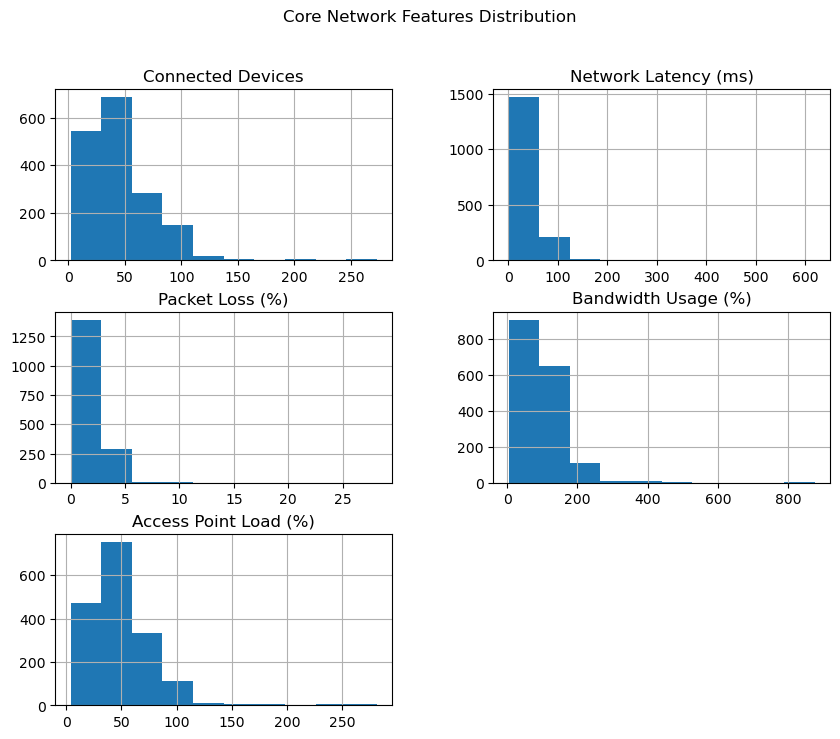

In [13]:
#EDA
#Distribution
df[network_core].hist(figsize=(10,8))
plt.suptitle("Core Network Features Distribution")
plt.show()




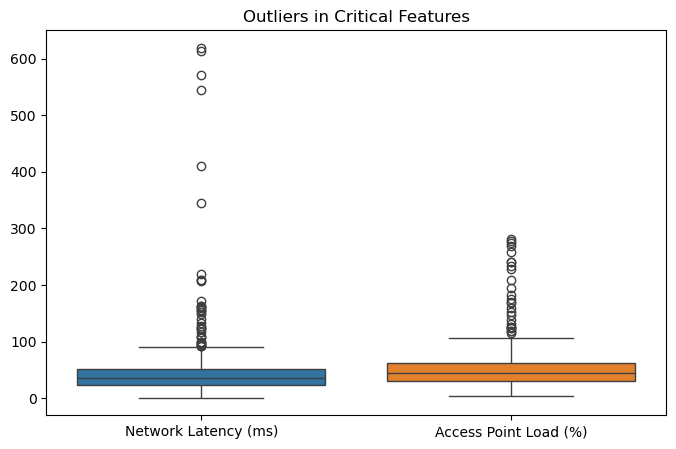

In [14]:
#Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Network Latency (ms)', 'Access Point Load (%)']])
plt.title("Outliers in Critical Features")
plt.show()

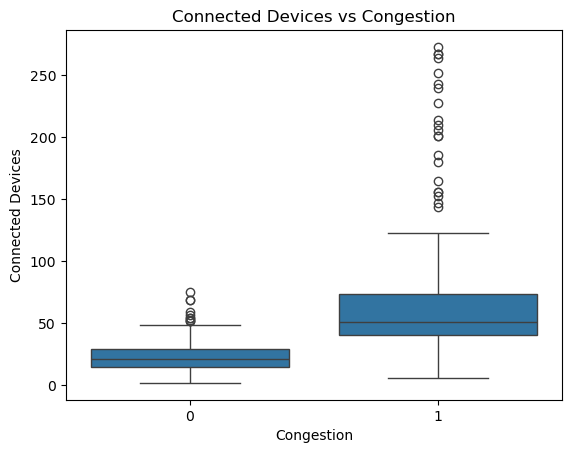

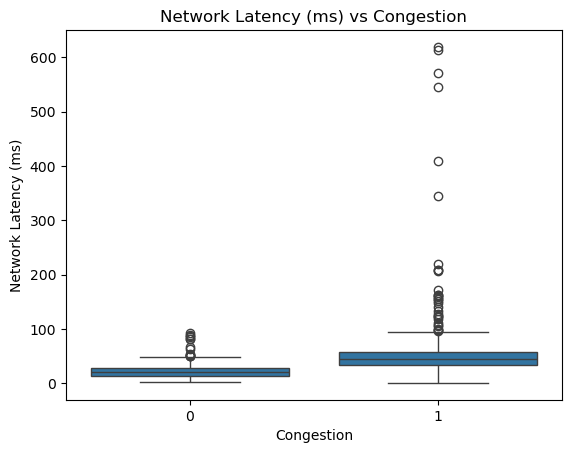

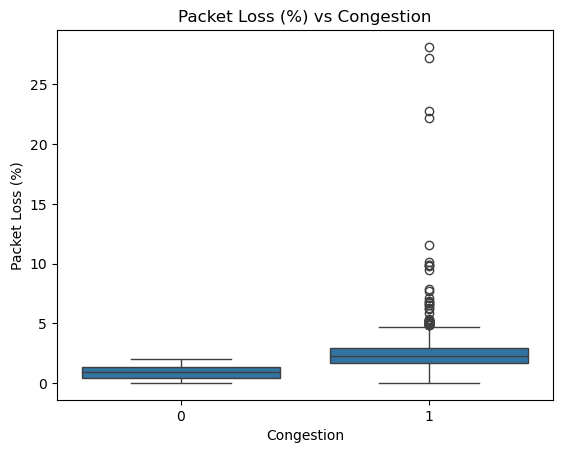

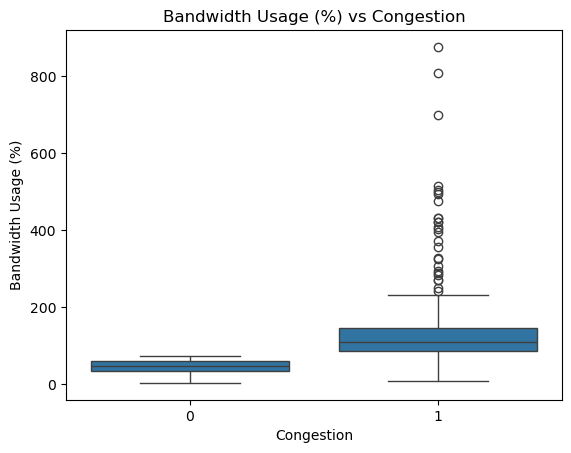

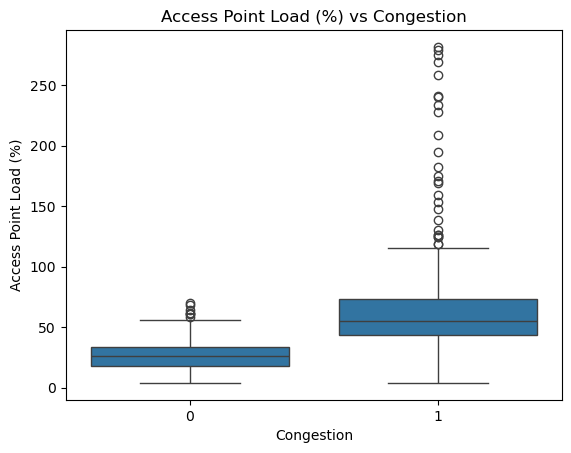

In [16]:
# Congestion vs Features
for col in network_core:
    plt.figure()
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} vs Congestion")
    plt.show()


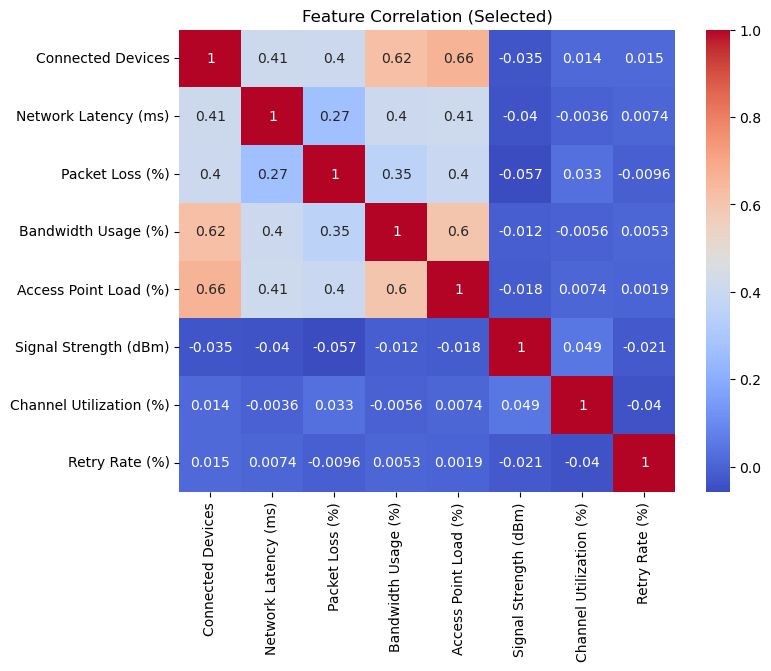

In [17]:
# Correlation
plt.figure(figsize=(8,6))
corr = df[network_core + network_extra].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation (Selected)")
plt.show()

In [19]:
# PREPROCESSING
df.fillna(df.mean(numeric_only=True), inplace=True)
df

,Connected Devices,Network Latency (ms),Packet Loss (%),Bandwidth Usage (%),Access Point Load (%),Signal Strength (dBm),Channel Utilization (%),Retry Rate (%),Congestion
0,40.000000,20.200000,1.04,79.3,47.50000,-76,48.467361,1.212207,1
1,106.000000,79.600000,4.53,206.4,84.90000,-39,57.915882,1.913272,1
2,30.000000,41.140059,2.23,64.8,49.15492,-47,90.882375,0.758339,1
3,63.000000,123.300000,3.20,122.3,49.15492,-56,99.792660,9.136327,1
4,46.412111,27.000000,3.30,117.6,51.90000,-81,77.804930,16.517069,1
...,...,...,...,...,...,...,...,...,...
1795,76.000000,58.400000,2.58,178.0,74.90000,-73,92.601606,11.241563,1
1796,59.000000,38.400000,2.44,132.1,54.00000,-77,70.008046,19.869670,1
1797,17.000000,25.200000,1.14,138.9,49.15492,-78,52.442434,9.114267,1
1798,68.000000,56.600000,2.54,140.4,62.00000,-59,80.128460,14.278854,1


In [22]:
# Outlier Treatment
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

cap_outliers('Network Latency (ms)')
cap_outliers('Packet Loss (%)')

In [23]:
# FEATURE SELECTION
corr_matrix = df[network_core + network_extra].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Dropped due to high correlation:", to_drop)

X = df.drop(columns=[target] + to_drop)
y = df[target]

Dropped due to high correlation: []


In [24]:
# SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (1800, 8)
Reduced shape: (1800, 7)


In [26]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [27]:
# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

Logistic Regression Accuracy: 0.9055555555555556


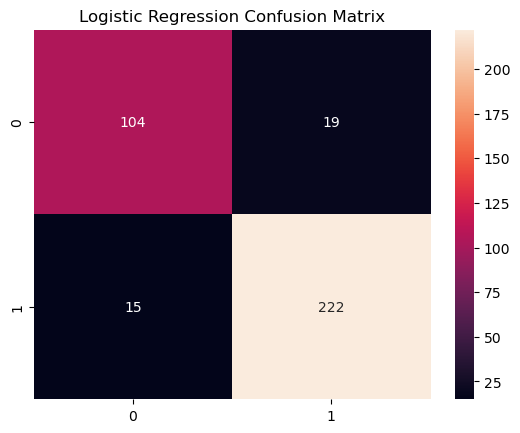

Random Forest Accuracy: 0.9138888888888889


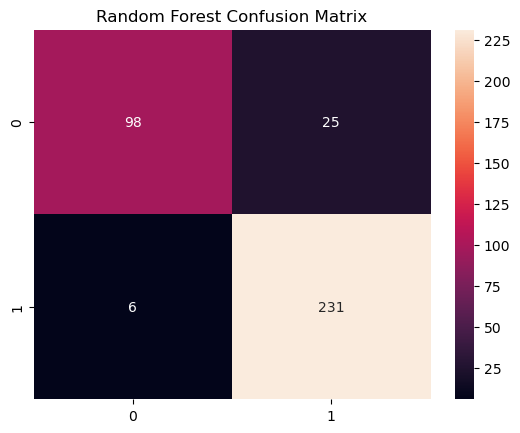

SVM Accuracy: 0.9166666666666666


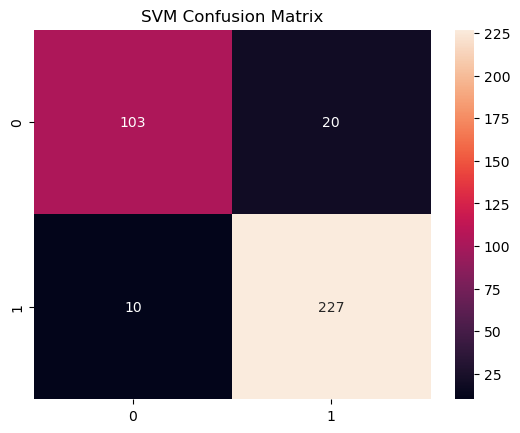

In [28]:
# EVALUATION
from sklearn.metrics import accuracy_score, confusion_matrix

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy:", acc)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()